In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
samithsachidanandan_human_face_emotions_path = kagglehub.dataset_download('samithsachidanandan/human-face-emotions')

print('Data source import complete.')


c:\Users\18217\anaconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

!pip install tensorflow

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import matplotlib.pyplot as plt
import os

In [3]:
dataset_dir = os.path.join(samithsachidanandan_human_face_emotions_path, 'Data')


In [4]:
IMG_WIDTH=128
IMG_HEIGHT=128
SEED=281
VALIDATION_SPLIT=0.2
BATCH_SIZE=64

train_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 59099 files belonging to 5 classes.
Using 47280 files for training.
Found 59099 files belonging to 5 classes.
Using 11819 files for validation.


In [5]:
def plot_training_history(history):
    """Plots training and validation metrics (loss and accuracy) over epochs."""

    # Extract data from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # --- Plot 1: Loss ---
    plt.subplot(1, 2, 1) # 1 row, 2 columns, plot 1
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')

    # --- Plot 2: Accuracy ---
    plt.subplot(1, 2, 2) # 1 row, 2 columns, plot 2
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')

    plt.tight_layout()
    plt.show()

In [6]:
model = keras.Sequential([
    layers.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,789 (8.36 MB)

 Trainable params: 2,190,789 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 196s 228ms/step - accuracy: 0.4271 - loss: 1.3694 - val_accuracy: 0.4989 - val_loss: 1.2094
Epoch 2/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 157s 212ms/step - accuracy: 0.5310 - loss: 1.1535 - val_accuracy: 0.5584 - val_loss: 1.0796
Epoch 3/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 154s 209ms/step - accuracy: 0.5793 - loss: 1.0485 - val_accuracy: 0.5943 - val_loss: 1.0074
Epoch 4/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 155s 210ms/step - accuracy: 0.6194 - loss: 0.9574 - val_accuracy: 0.6305 - val_loss: 0.9227
Epoch 5/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 169s 228ms/step - accuracy: 0.6512 - loss: 0.8814 - val_accuracy: 0.6569 - val_loss: 0.8798
Epoch 6/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 158s 214ms/step - accuracy: 0.6879 - loss: 0.8024 - val_accuracy: 0.6759 - val_loss: 0.8286
Epoch 7/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 155s 210ms/step - accuracy: 0.7124 - loss: 0.7403 - val_accuracy: 0.6991 - val_loss: 0.7945
Epoch 8/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 151s 205ms/step - accuracy: 0.7381 -

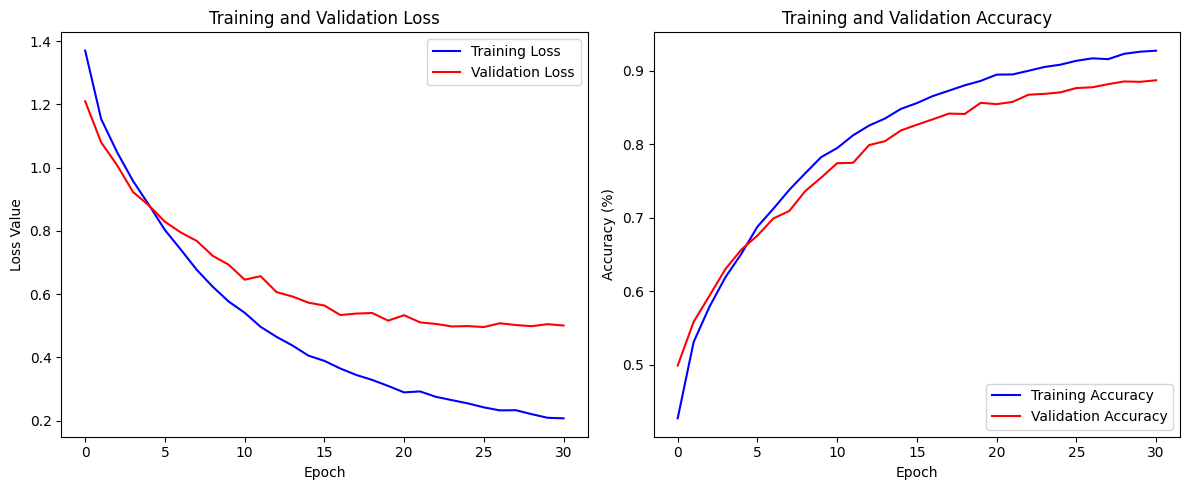

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

plot_training_history(history)